# N4 · Demo GraphFrames motif 3 đỉnh (21/9)

**Phạm vi:** toy graph A → B → C → A; chạy đúng mẫu `(a)-[e1]->(b);(b)-[e2]->(c);(c)-[e3]->(a)`. Chạy bằng kernel Windows `.venv\Scripts\python.exe` để xem trạng thái và ba phép xoay của chu trình.


## Trạng thái công việc N4 ngày 21/9

| Hạng mục | Trạng thái | Bằng chứng |
| --- | --- | --- |
| Cài môi trường Windows `.venv` | ✅ PASS | `pip check` không có lỗi |
| Tạo toy GraphFrame | ✅ PASS | 3 đỉnh, 3 cạnh có hướng |
| Chạy `graph.find()` | ✅ PASS | 3 dòng motif, 1 chu trình duy nhất |
| Viết báo cáo | ✅ PASS | `docs/N4_Motif_Toy_2026-09-21.md` |

PowerShell: xem lệnh chạy trong `README.md` hoặc `docs/N4_Motif_Toy_2026-09-21.md`.


In [1]:
from pathlib import Path
import sys
import os
import importlib.metadata
from html import escape
from IPython.display import HTML, SVG, display
import pyspark

if os.name != 'nt':
    raise RuntimeError('Chọn kernel Windows .venv\\Scripts\\python.exe để chạy notebook')

repo = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / "requirements.txt").is_file() and (path / "src").is_dir())
sys.path.insert(0, str(repo))
from src.common.spark_session import get_graph_session
from src.motif.toy_cycle import MOTIF_PATTERN, build_toy_graph, find_three_node_cycles, cycle_ids, run_demo

spark = get_graph_session("GraphGuard-N4-Notebook")
spark.sparkContext.setLogLevel("ERROR")
graph = build_toy_graph(spark)
print(f"Python: {sys.executable}")
print(f"PySpark {pyspark.__version__} · graphframes-py {importlib.metadata.version('graphframes-py')}")
print(f"Vertices: {graph.vertices.count()} · Edges: {graph.edges.count()}")
display(HTML("<b>Vertices</b><pre>" + escape(str([(r.id, r.name) for r in graph.vertices.orderBy('id').collect()])) + "</pre>"))
display(HTML("<b>Edges</b><pre>" + escape(str([(r.src, r.dst) for r in graph.edges.orderBy('src').collect()])) + "</pre>"))


Python: D:\Desktop_informations\SGK năm 4\SGK kì 1 năm 4\BigData - Phong\Project_graphX\graphguard-amls-detection\.venv\Scripts\python.exe
PySpark 3.5.1 · graphframes-py 0.12.2


Vertices: 3 · Edges: 3


## Truy vấn motif

`graph.find()` ghép các cạnh có hướng thành đường khép kín. Điều kiện ID khác nhau đảm bảo đây là chu trình **ba đỉnh riêng biệt**. Mỗi cách chọn đỉnh bắt đầu tạo một dòng kết quả.


In [2]:
print(f'graph.find("{MOTIF_PATTERN}")')
raw = cycle_ids(find_three_node_cycles(graph)).orderBy("a").collect()
rows_html = "".join(f"<tr><td>{escape(r.a)}</td><td>{escape(r.b)}</td><td>{escape(r.c)}</td></tr>" for r in raw)
display(HTML("<table style='border-collapse:collapse'><thead><tr><th style='padding:8px'>a</th><th style='padding:8px'>b</th><th style='padding:8px'>c</th></tr></thead><tbody>" + rows_html + "</tbody></table>"))
print(f"Số dòng motif: {len(raw)}")


graph.find("(a)-[e1]->(b);(b)-[e2]->(c);(c)-[e3]->(a)")


a,b,c
A,B,C
B,C,A
C,A,B


Số dòng motif: 3


## Trạng thái demo

Ba dòng A→B→C, B→C→A, C→A→B biểu diễn **một** chu trình duy nhất sau khi chuẩn hóa theo ID nhỏ nhất.


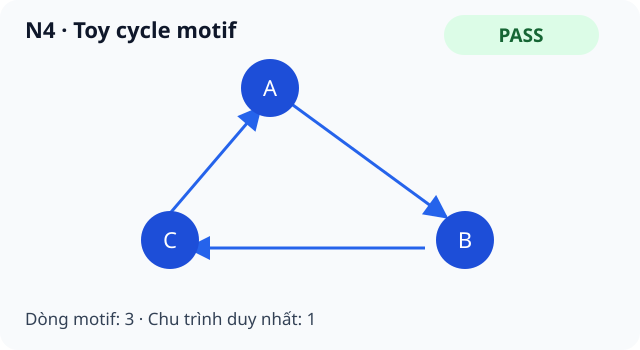

Kết quả: [['A', 'B', 'C'], ['B', 'C', 'A'], ['C', 'A', 'B']]


In [3]:
result = run_demo(spark)
svg = f"""<svg xmlns='http://www.w3.org/2000/svg' width='640' height='350' viewBox='0 0 640 350'>
<defs><marker id='arrow' markerWidth='8' markerHeight='8' refX='7' refY='4' orient='auto'><path d='M0 0 L8 4 L0 8 z' fill='#2563eb'/></marker></defs>
<rect width='640' height='350' rx='18' fill='#f8fafc'/>
<text x='25' y='38' font-size='22' font-family='sans-serif' font-weight='bold' fill='#0f172a'>N4 · Toy cycle motif</text>
<rect x='444' y='15' width='155' height='40' rx='20' fill='#dcfce7'/>
<text x='521' y='42' text-anchor='middle' font-size='19' font-family='sans-serif' font-weight='bold' fill='#166534'>{result['status']}</text>
<path d='M286 100 L446 217' stroke='#2563eb' stroke-width='3' marker-end='url(#arrow)'/>
<path d='M425 248 L189 248' stroke='#2563eb' stroke-width='3' marker-end='url(#arrow)'/>
<path d='M166 218 L260 108' stroke='#2563eb' stroke-width='3' marker-end='url(#arrow)'/>
<circle cx='270' cy='88' r='29' fill='#1d4ed8'/><text x='270' y='96' text-anchor='middle' font-size='22' font-family='sans-serif' fill='white'>A</text>
<circle cx='465' cy='240' r='29' fill='#1d4ed8'/><text x='465' y='248' text-anchor='middle' font-size='22' font-family='sans-serif' fill='white'>B</text>
<circle cx='170' cy='240' r='29' fill='#1d4ed8'/><text x='170' y='248' text-anchor='middle' font-size='22' font-family='sans-serif' fill='white'>C</text>
<text x='25' y='325' font-size='17' font-family='sans-serif' fill='#334155'>Dòng motif: {result['raw_match_count']}  ·  Chu trình duy nhất: {result['unique_cycle_count']}</text>
</svg>"""
display(SVG(svg))
print("Kết quả:", result['raw_matches'])


In [4]:
spark.stop()
print("SparkSession đã dừng; demo hoàn tất.")


SparkSession đã dừng; demo hoàn tất.
